# Normal (Gaussian) Distribution

The normal distribution curve is a symmetrical, “bell-shaped” curve similar to a histogram. A normal distribution is completely described by its mean $\mu$ and standard deviation $\sigma$.

Normal distributions can be denoted as $\mathcal{N}(\mu, \sigma^2)$, where $\mu$ is the mean and $\sigma^2$ is the variance.

When the normal distribution has a $\mu$ of 0 and a $\sigma$ of 1, it is called the *standard normal distribution* $\mathcal{N}(0,1)$ - in this special case $\sigma^2 = \sigma$  because $1^2 = 1$.

In [114]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import math

In [115]:
n = np.random.normal(size=10000)

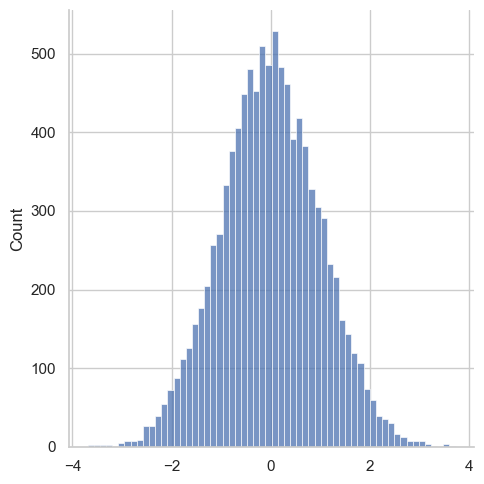

In [116]:
_ = sns.displot(n)

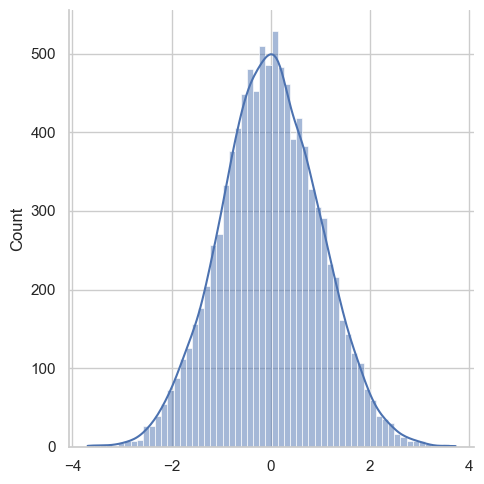

In [117]:
_ = sns.displot(n, kde=True)

### Observations

- 99.7% of the values are in an interval around $\mu \pm 3\sigma$.
- 95% of the values are in an interval around $\mu \pm 2\sigma$.
- 68% of the values are in an interval around $\mu \pm 1\sigma$.

**These percentages are unique to the normal distribution.**

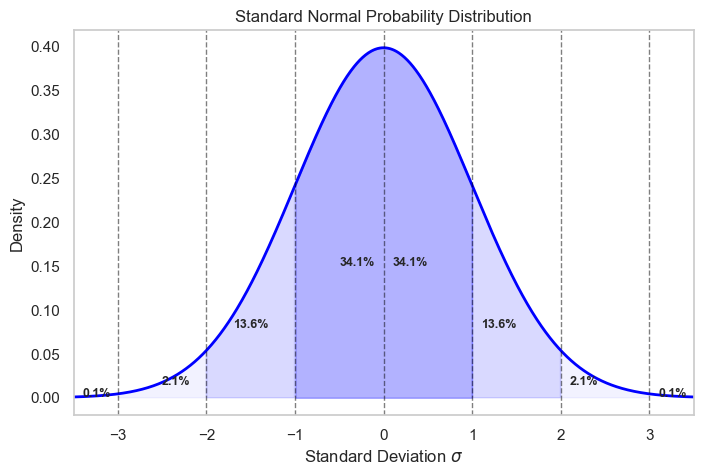

In [118]:
# Parameters for the normal distribution
mean = 0
std = 1

# Generate data for the normal distribution
x = np.linspace(-4, 4, 1000)
pdf = norm.pdf(x, loc=mean, scale=std)

# Plot the PDF using seaborn
plt.figure(figsize=(8, 5))
sns.lineplot(x=x, y=pdf, color='blue', linewidth=2)

# Fill the standard deviation regions
plt.fill_between(x, pdf, where=(x >= -1) & (x <= 1), color='blue', alpha=0.3)
plt.fill_between(x, pdf, where=((x >= -2) & (x <= -1)) | ((x >= 1) & (x <= 2)), color='blue', alpha=0.15)
plt.fill_between(x, pdf, where=((x >= -3) & (x <= -2)) | ((x >= 2) & (x <= 3)), color='blue', alpha=0.05)

# Add vertical lines at multiples of sigma
for i in range(-3, 4):
    plt.axvline(i, color='black', linewidth=1, linestyle='--', alpha=0.5)

# Annotate the classic rule-of-thumb percentages
plt.text(-0.3, 0.15, "34.1%", fontsize=9, ha='center', weight='bold')
plt.text(-1.5, 0.08, "13.6%", fontsize=9, ha='center', weight='bold')
plt.text(-2.5, 0.015, "2.1%", fontsize=9, weight='bold')
plt.text(-3.4, 0.001, "0.1%", fontsize=9, weight='bold')
plt.text(0.1, 0.15, "34.1%", fontsize=9, ha='left', weight='bold')
plt.text(1.1, 0.08, "13.6%", fontsize=9, ha='left', weight='bold')
plt.text(2.1, 0.015, "2.1%", fontsize=9, weight='bold')
plt.text(3.1, 0.001, "0.1%", fontsize=9, ha='left', weight='bold')

# Labeling and aesthetics
plt.xlim(-3.5, 3.5)
plt.title("Standard Normal Probability Distribution")
plt.xlabel("Standard Deviation" + ' ' + r'$\sigma$')
plt.ylabel("Density")
plt.grid(False)
plt.show()

It is one of the most common distributions and typically the default option, especially when there is limited information available about the random process being modeled.

- Assumes the greatest possible uncertainty about the random variables it represents (relative to other distributions).
- In simple and complex random processes are, under common conditions, normally distributed when values are sampled from that process.

#### Examples of the normal (Gaussian) distribution

#### Example

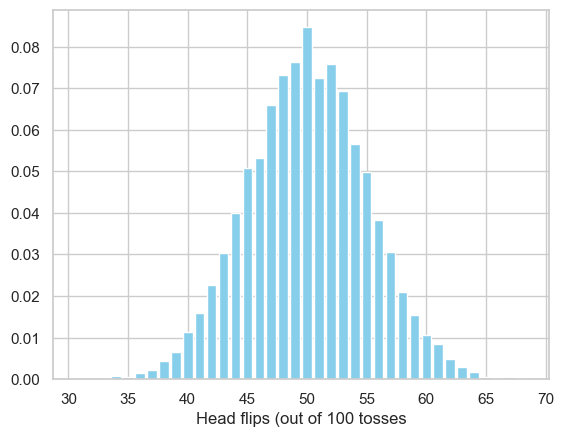

In [123]:
n_experiments = 10000
heads_count = np.random.binomial(100, 0.5, n_experiments)
heads, event_count = np.unique(heads_count, return_counts=True)
event_proba = event_count/n_experiments
plt.bar(heads, event_proba, color='skyblue')
_ = plt.xlabel('Head flips (out of 100 tosses')

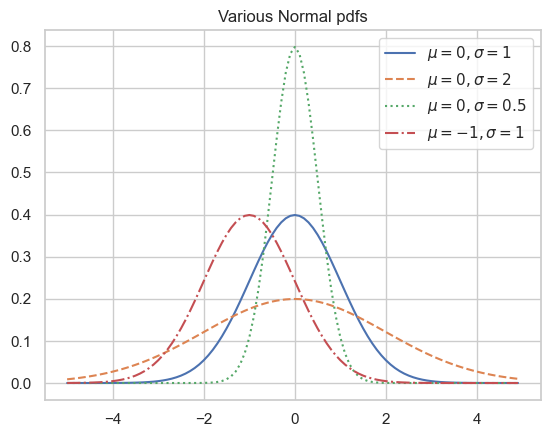

In [124]:
SQRT_TWO_PI = math.sqrt(2 * math.pi)

def normal_pdf(x: float, mu: float = 0, sigma: float = 1) -> float:
    return (math.exp(-(x-mu) ** 2 / 2 / sigma ** 2) / (SQRT_TWO_PI * sigma))

xs = [x / 10.0 for x in range(-50, 50)]
plt.plot(xs,[normal_pdf(x,sigma=1) for x in xs],'-',label=r'$\mu=0,\sigma=1$')
plt.plot(xs,[normal_pdf(x,sigma=2) for x in xs],'--',label=r'$\mu=0,\sigma=2$')
plt.plot(xs,[normal_pdf(x,sigma=0.5) for x in xs],':',label=r'$\mu=0,\sigma=0.5$')
plt.plot(xs,[normal_pdf(x,mu=-1)   for x in xs],'-.',label=r'$\mu=-1,\sigma=1$')
plt.legend()
plt.title("Various Normal pdfs")
plt.show()